In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
data = {
    "Area" : np.array([100, 200, 300, 400, 500, 600, 700]),   #square ft
    "Price" : np.array([1000, 2000, 3000, 4000, 5000, 6000, 7000]) # Price
}

In [3]:
#NOTE : creating dataframe for model to train
df = pd.DataFrame(data=data)

In [4]:
#NOTE : initializing the model 
#NOTE : Before training, a model must have defined parameters (weights & biases). 
# Training is just the process of updating those parameters, so something has to exist first.
model = LinearRegression()

In [5]:
X = df[['Area']]
Y = df['Price']

In [6]:
#NOTE: Training model 
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
#NOTE: Predicting the price of the house when the area is 12000 sq.ft
new_house_area = pd.DataFrame([150, 250, 350, 450, 650, 750, 850], columns=['Area'])
predicted_price =   model.predict(new_house_area) # sklearn always returns 1D array
#NOTE: since y is 1D so the predicted version will also be 1D therefore we cannot use :.2f since it is not scalar and it
# is a 1D array so in order to use :.2f we need to make 2D i.e; [0][0]
print(f"The price of the house with area {new_house_area.iloc[0, 0]} sq.ft is {predicted_price[0]:.2f} Rs")

The price of the house with area 150 sq.ft is 1500.00 Rs


In [8]:
#NOTE: Best fit line 
m = model.coef_.item()  #this means extracting coeff. of [X] i.e ; m since y = mx + c
c = model.intercept_.item()     # .item() will help us to get arrays into scalars

print(f"The best fit equation is : y = ({m:.2f})x + ({c:.2f})")

The best fit equation is : y = (10.00)x + (-0.00)


# Classification metics - use checking i)Accuracy, ii)Precision , iii)Recall and iv)F1 Score


In [9]:
#NOTE: importing necessary libraries from sklearn required for classification metrics
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, precision_score, recall_score, f1_score

MSE = mean_squared_error(Y,predicted_price)
print(f"The MSE of the above linear model is : {MSE}")
R2_score = r2_score(Y, predicted_price)
print(f"The r2_score of above model is : {R2_score}")

print("---------------------------------------------")
#NOTE: This can be only done if the data has y in class labels , and are not continous
print("---------------------------------------------")

# print(f"The Accuracy of the above model is : {accuracy_score(Y, predicted_price)}")
# print(f"The Precision of the above model is : {precision_score(Y, predicted_price)}")
# print(f"The Recall score of the above model is : {recall_score(Y, predicted_price)}")
# print(f"The F1 score of the above model is : {f1_score(Y, predicted_price)}")



The MSE of the above linear model is : 1107142.8571428568
The r2_score of above model is : 0.7232142857142858
---------------------------------------------
---------------------------------------------


# Visualizing the Best fit line 

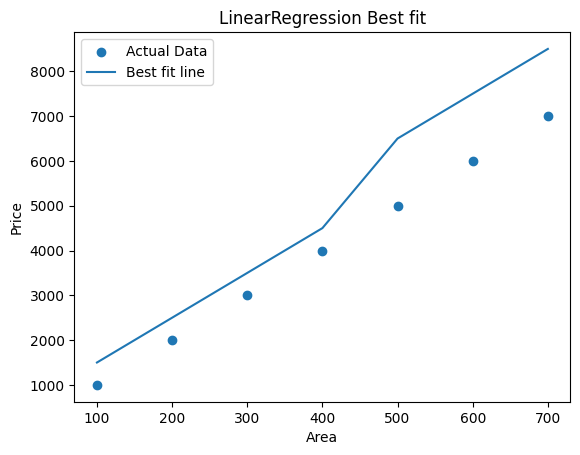

In [10]:
plt.scatter(df['Area'], df['Price'], label="Actual Data")
plt.plot(df['Area'],predicted_price, label="Best fit line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("LinearRegression Best fit")
plt.legend()
plt.show()


In [11]:
#NOTE: adding columns for Residual analysis
df['ŷ'] = predicted_price
residuals = Y - predicted_price
df['Residuals (y-ŷ)'] = residuals
df['Residual² (y-ŷ)²'] = residuals * residuals
df


,Area,Price,ŷ,Residuals (y-ŷ),Residual² (y-ŷ)²
0,100,1000,1500.0,-500.0,250000.0
1,200,2000,2500.0,-500.0,250000.0
2,300,3000,3500.0,-500.0,250000.0
3,400,4000,4500.0,-500.0,250000.0
4,500,5000,6500.0,-1500.0,2250000.0
5,600,6000,7500.0,-1500.0,2250000.0
6,700,7000,8500.0,-1500.0,2250000.0


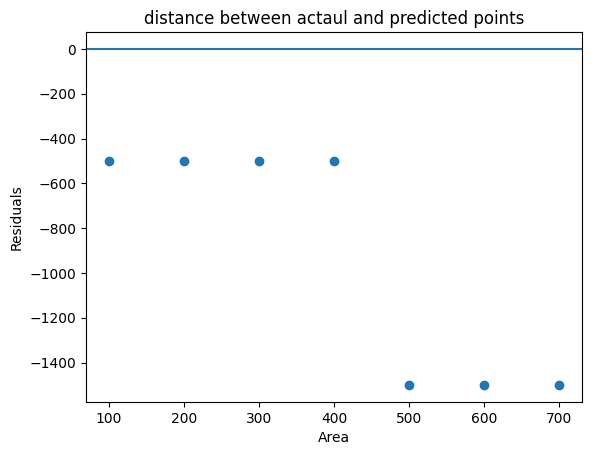

In [12]:
plt.scatter(df['Area'], residuals)
plt.axhline(0)
plt.xlabel("Area")
plt.ylabel("Residuals")
plt.title("distance between actaul and predicted points")
plt.show()